***Random Forst Regressor***

In [2]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [3]:
# Loading the csv data
gold_data = pd.read_csv('gld_price_data.csv')
gold_data

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.1800,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.2850,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.1670,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.0530,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...,...
2285,5/8/2018,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.380000,15.5600,1.193118


In [35]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [36]:
# Last 5 rows
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [37]:
# Number of rows and columns
gold_data.shape

(2290, 6)

In [38]:
# Data info
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [39]:
# Removing the Date column
gold_data = gold_data.drop('Date', axis=1)

In [40]:
# Checking for null values
gold_data.isnull().sum()

SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [41]:
# Finding correlation between features
# In regression, correlation helps identify which features (like SPX, USO, SLV) most influence gold prices
correlation = gold_data.corr()

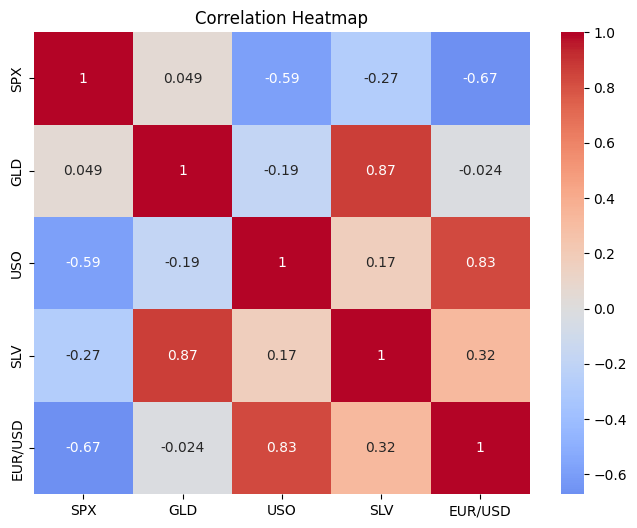

In [42]:
# Constructing a heatmap to understand the correlation
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [43]:
# Correlation values of GLD (gold) with other features
correlation['GLD']

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64

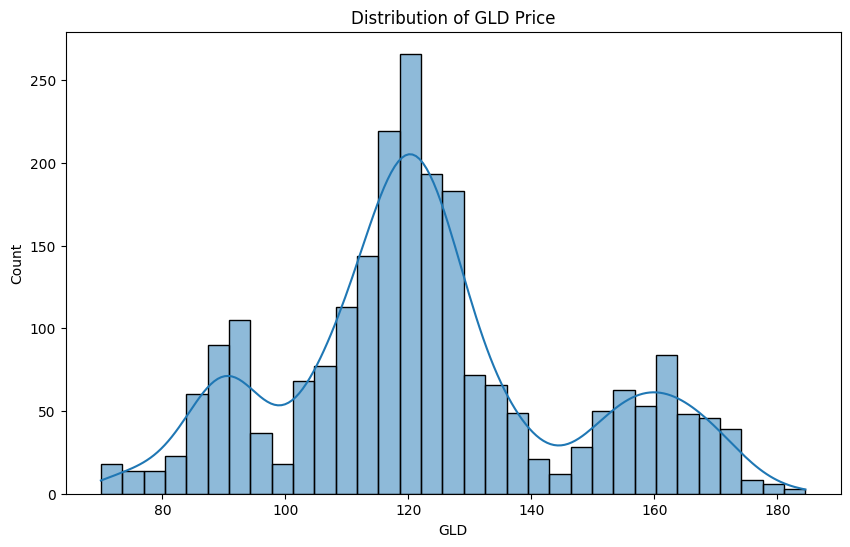

In [44]:
# Check the distribution of GLD price
plt.figure(figsize=(10,6))
sns.histplot(gold_data['GLD'], kde=True)
plt.title('Distribution of GLD Price')
plt.show()

In [45]:
# Splitting the features and target
X = gold_data.drop('GLD', axis=1)
y = gold_data['GLD']

In [46]:
# Partioning the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=43
)

In [47]:
# Model training : Random forest
rf_model = RandomForestRegressor(
    random_state=43
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=43)

In [48]:
# Model Evaluation
y_pred = rf_model.predict(X_test)
y_pred

array([120.3850004 , 120.15109946, 165.03430125,  89.29679968,
       125.30929959, 140.47880017,  91.13660092, 160.92469959,
       127.51209933,  90.83760017, 104.68450013, 125.41900072,
       118.57760027, 160.41490135,  88.40509908, 124.16930095,
       107.15250157, 115.51669855, 110.32500049, 114.97900023,
       118.72260086, 106.73409857, 122.89929784, 126.2257997 ,
       122.59999988, 170.10439971, 118.65070172, 121.71909884,
       145.01350231, 107.95660066, 131.90849879, 160.50969818,
       105.07370106, 107.2494998 ,  94.52480086, 161.61390429,
       114.57930016, 113.86279891, 125.28790116, 113.94430105,
       103.08570054, 106.84059966, 122.44419946, 158.84119931,
       115.53099948, 115.79850088, 154.59450069, 155.49450407,
       110.30569796,  80.71259971, 128.19270113, 119.96240162,
       153.40059868,  96.16059909, 127.77160087, 114.57139999,
       112.83310121, 155.06080009, 168.02879889,  91.73369947,
       117.92390055,  87.09299777, 135.8020987 , 156.87

In [49]:
# We are going to use the R2 score to evaluate the model
metrics.r2_score(y_test, y_pred)

0.9880228654952938

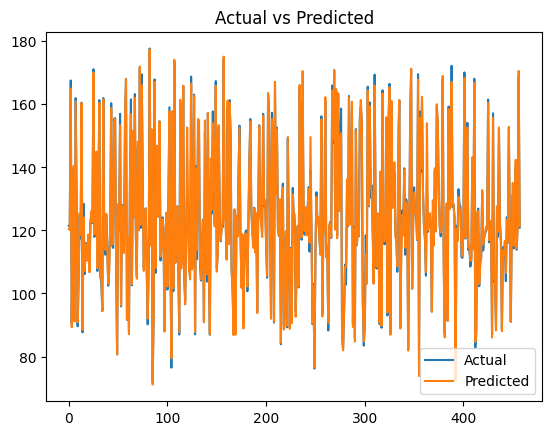

In [ ]:
# Comparing the y_pred and y_test
import matplotlib.pyplot as plt
plt.plot(list(y_test), label='Actual')
plt.plot(list(y_pred), label='Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()